<a href="https://colab.research.google.com/github/BigBisus/LeonovLabs/blob/master/leonov_lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Embedding,
    GRU,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
print("GPU devices:")
print(tf.config.list_physical_devices('GPU'))

GPU devices:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
max_features = 10001

maxlen = 500

embedding_dim = 64

gru_units = 128

batch_size = 128

epochs = 35

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=max_features
)

print("Размер обучающей выборки:", len(x_train))
print("Размер тестовой выборки:", len(x_test))

Размер обучающей выборки: 25000
Размер тестовой выборки: 25000


In [ ]:
x_train = pad_sequences(
    x_train,
    maxlen=maxlen
)

x_test = pad_sequences(
    x_test,
    maxlen=maxlen
)

print("Форма x_train:", x_train.shape)
print("Форма x_test:", x_test.shape)

Форма x_train: (25000, 500)
Форма x_test: (25000, 500)


In [ ]:
model_gru = Sequential()

model_gru.add(
    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim
    )
)

model_gru.add(
    GRU(
        gru_units,
        dropout=0.2
    )
)

model_gru.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_gru.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6283 - loss: 0.6307 - val_accuracy: 0.7568 - val_loss: 0.5046
Epoch 2/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.7901 - loss: 0.4528 - val_accuracy: 0.8392 - val_loss: 0.4168
Epoch 3/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8229 - loss: 0.3991 - val_accuracy: 0.8218 - val_loss: 0.3920
Epoch 4/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.8479 - loss: 0.3596 - val_accuracy: 0.8312 - val_loss: 0.3803
Epoch 5/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8687 - loss: 0.3186 - val_accuracy: 0.8444 - val_loss: 0.3963
Epoch 6/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8753 - loss: 0.3040 - val_accuracy: 0.8344 - val_loss: 0.3768
Epoch 7/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8839 - loss: 0.2841 - val_accuracy: 0.8738 - val_loss: 0.3152
Epoch 8/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - accuracy: 0.8953 - loss: 0.2637 - val_ac

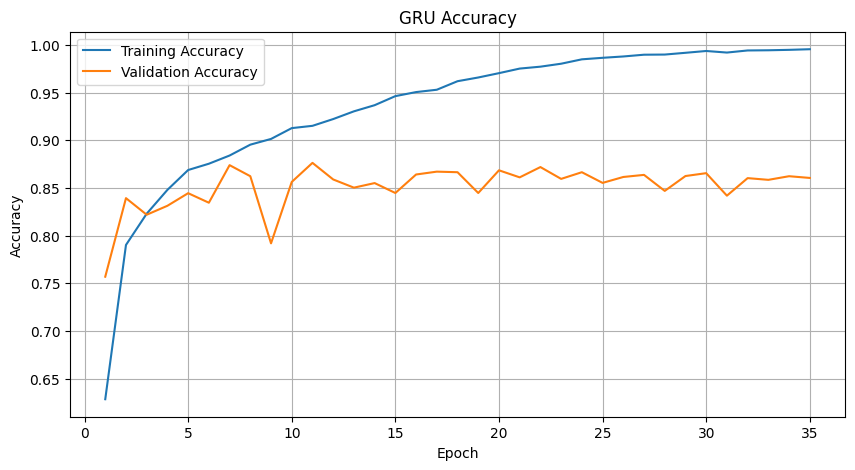

In [ ]:
acc = history_gru.history['accuracy']
val_acc = history_gru.history['val_accuracy']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy'
)

plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid()

plt.show()

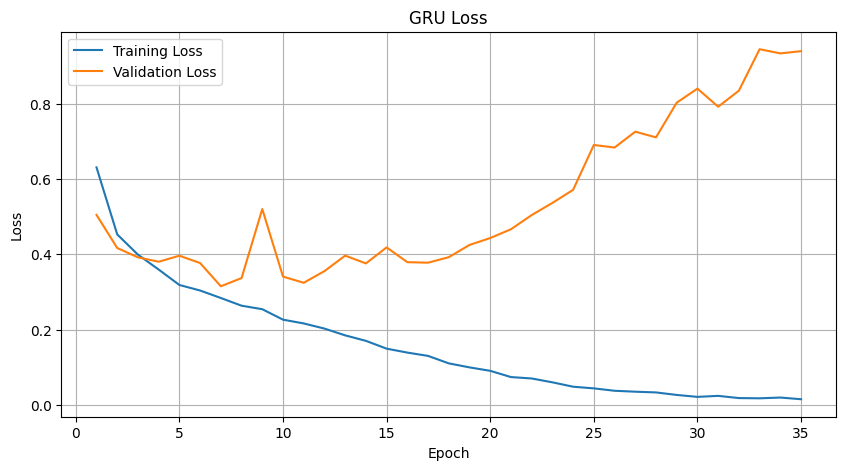

In [ ]:
loss = history_gru.history['loss']
val_loss = history_gru.history['val_loss']

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    loss,
    label='Training Loss'
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss'
)

plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid()

plt.show()

In [ ]:
test_loss, test_acc = model_gru.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8593 - loss: 0.9636
Test Accuracy: 0.8593199849128723
Test Loss: 0.9635629057884216


In [ ]:
predictions = model_gru.predict(x_test[:10])

for i in range(10):

    print(f"\nОтзыв {i+1}")

    print("Вероятность положительного отзыва:",
          predictions[i][0])

    if predictions[i][0] > 0.5:
        print("Положительный отзыв")
    else:
        print("Отрицательный отзыв")

    print("Правильный ответ:", y_test[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step

Отзыв 1
Вероятность положительного отзыва: 0.0476
Отрицательный отзыв
Правильный ответ: 0

Отзыв 2
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 3
Вероятность положительного отзыва: 0.0
Отрицательный отзыв
Правильный ответ: 1

Отзыв 4
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 0

Отзыв 5
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 6
Вероятность положительного отзыва: 0.151
Отрицательный отзыв
Правильный ответ: 1

Отзыв 7
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1

Отзыв 8
Вероятность положительного отзыва: 0.0
Отрицательный отзыв
Правильный ответ: 0

Отзыв 9
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 0

Отзыв 10
Вероятность положительного отзыва: 1.0
Положительный отзыв
Правильный ответ: 1


In [ ]:
model_conv = Sequential()

model_conv.add(
    Embedding(
        input_dim=max_features,
        output_dim=embedding_dim,
        input_length=maxlen
    )
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    MaxPooling1D(5)
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    MaxPooling1D(5)
)

model_conv.add(
    Conv1D(
        32,
        7,
        activation='relu'
    )
)

model_conv.add(
    GlobalMaxPooling1D()
)

model_conv.add(
    Dense(1, activation='sigmoid')
)

model_conv.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_conv.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_conv = model_conv.fit(
    x_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2
)

Epoch 1/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 372ms/step - accuracy: 0.5883 - loss: 0.6712 - val_accuracy: 0.7400 - val_loss: 0.5313
Epoch 2/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.8032 - loss: 0.4324 - val_accuracy: 0.8300 - val_loss: 0.3928
Epoch 3/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8606 - loss: 0.3299 - val_accuracy: 0.8582 - val_loss: 0.3394
Epoch 4/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8929 - loss: 0.2661 - val_accuracy: 0.8666 - val_loss: 0.3197
Epoch 5/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9128 - loss: 0.2236 - val_accuracy: 0.8706 - val_loss: 0.3211
Epoch 6/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9324 - loss: 0.1791 - val_accuracy: 0.8524 - val_loss: 0.4272
Epoch 7/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9474 - loss: 0.1441 - val_accuracy: 0.8642 - val_loss: 0.3855
Epoch 8/35
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9657 - loss: 0.0998 - val_ac

In [ ]:
conv_loss, conv_acc = model_conv.evaluate(
    x_test,
    y_test
)

print("Conv1D Accuracy:", conv_acc)
print("Conv1D Loss:", conv_loss)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8589 - loss: 1.3168
Conv1D Accuracy: 0.8589199781417847
Conv1D Loss: 1.3168343305587769


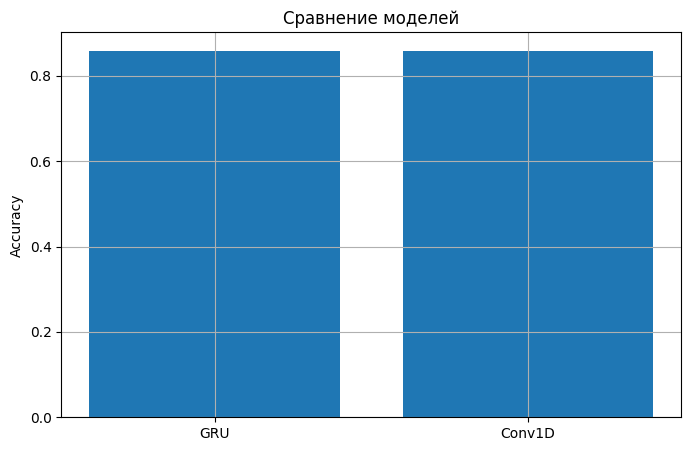

In [ ]:
models = ['GRU', 'Conv1D']
accuracies = [test_acc, conv_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title('Сравнение моделей')
plt.ylabel('Accuracy')

plt.grid()

plt.show()

In [ ]:

print("Точность GRU модели:", test_acc)
print("Точность Conv1D модели:", conv_acc)

if test_acc > conv_acc:
    print("\nGRU показала лучший результат.")
else:
    print("\nConv1D показала лучший результат.")

Точность GRU модели: 0.8593199849128723
Точность Conv1D модели: 0.8589199781417847

GRU показала лучший результат.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import timeseries_dataset_from_array

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


# Этап 2.1 — Загрузка набора данных Jena Climate

from google.colab import files
files.upload()

import zipfile

with zipfile.ZipFile("jena_climate.zip","r") as zip_ref:
    zip_ref.extractall("jena_climate")

df = pd.read_csv("jena_climate/jena_climate/jena_climate_2009_2016.csv")

print(df.head())
print("Размер данных:", df.shape)


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Saving jena_climate.zip to jena_climate (2).zip
             Date Time  p (mbar)  T (degC)  Tpot (K)  Tdew (degC)  rh (%)  \
0  01.01.2009 00:10:00    996.52     -8.02    265.40        -8.90    93.3   
1  01.01.2009 00:20:00    996.57     -8.41    265.01        -9.28    93.4   
2  01.01.2009 00:30:00    996.53     -8.51    264.91        -9.31    93.9   
3  01.01.2009 00:40:00    996.51     -8.31    265.12        -9.07    94.2   
4  01.01.2009 00:50:00    996.51     -8.27    265.15        -9.04    94.1   

   VPmax (mbar)  VPact (mbar)  VPdef (mbar)  sh (g/kg)  H2OC (mmol/mol)  \
0          3.33          3.11          0.22       1.94             3.12   
1          3.23          3.02          0.21       1.89             3.03   
2          3.21          3.01          0.20       1.88             3.02   
3          3.26          3.07          0.19       1.92             3.08   
4          3.27          3.08          0.19       1.92             3.09   

   rho (g/m**3)  wv (m/s)  max. wv (m/

Input: (128, 240, 14)
Target: (128,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 240, 128)       │        18,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 240, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,489 (91.75 KB)

 Trainable params: 23,489 (91.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - loss: 0.4448 - mae: 0.5180 - val_loss: 0.4045 - val_mae: 0.5088
Epoch 2/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - loss: 0.3873 - mae: 0.4884 - val_loss: 0.3945 - val_mae: 0.4986
Epoch 3/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - loss: 0.3683 - mae: 0.4761 - val_loss: 0.3625 - val_mae: 0.4773
Epoch 4/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - loss: 0.3443 - mae: 0.4608 - val_loss: 0.3332 - val_mae: 0.4566
Epoch 5/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - loss: 0.3932 - mae: 0.4920 - val_loss: 0.3699 - val_mae: 0.4846
Epoch 6/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - loss: 0.3757 - mae: 0.4806 - val_loss: 0.3609 - val_mae: 0.4733
Epoch 7/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - loss: 0.3603 - mae: 0.4700 - val_loss: 0.3297 - val_mae: 0.4511
Epoch 8/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - loss: 0.3529 - mae: 0.4655 - val_loss: 0.3376 - val_mae: 0.4559
Epoch 9/40
1551/1551 ━━━

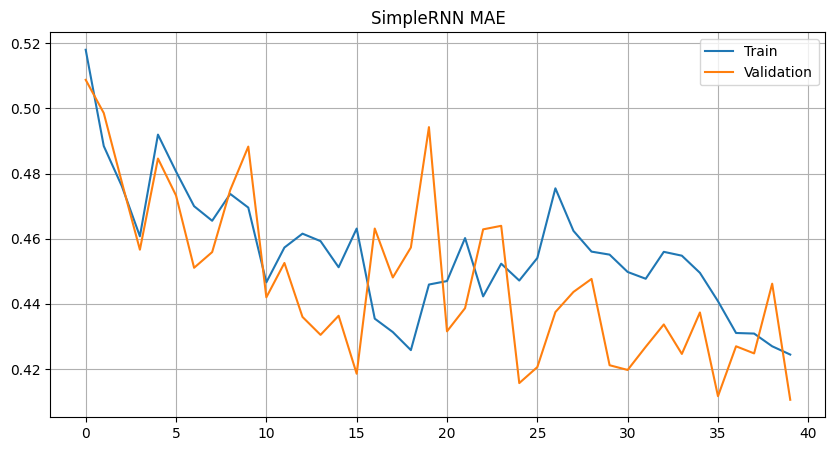

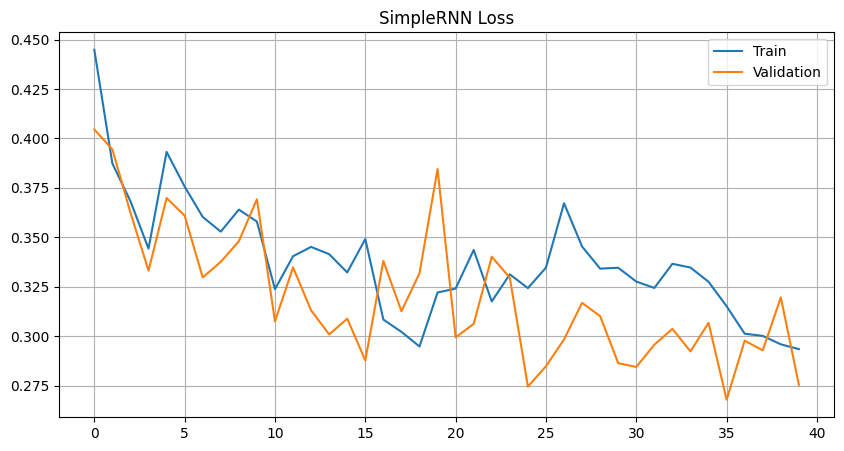

1320/1320 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step


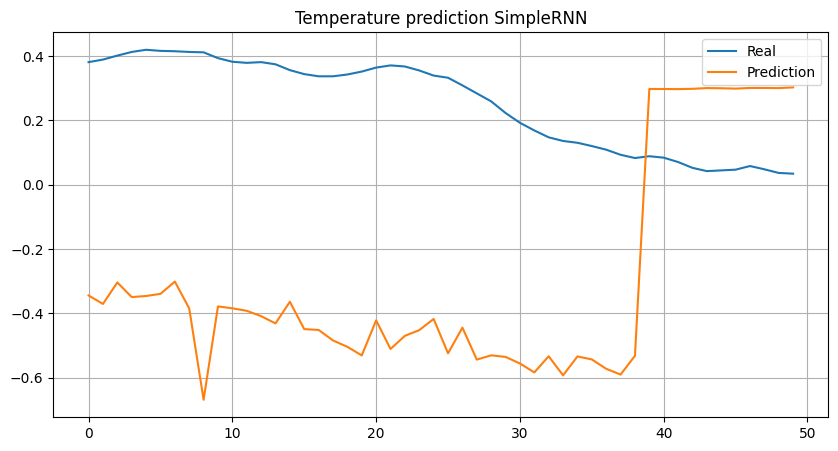

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 236, 32)        │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 78, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 74, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 32)         │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 20, 128)        │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,369 (149.88 KB)

 Trainable params: 38,369 (149.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 58s 33ms/step - loss: 0.1338 - mae: 0.2639 - val_loss: 0.0496 - val_mae: 0.1741
Epoch 2/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - loss: 0.0588 - mae: 0.1840 - val_loss: 0.0175 - val_mae: 0.1036
Epoch 3/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - loss: 0.0504 - mae: 0.1696 - val_loss: 0.0407 - val_mae: 0.1523
Epoch 4/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - loss: 0.0458 - mae: 0.1610 - val_loss: 0.0282 - val_mae: 0.1302
Epoch 5/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - loss: 0.0437 - mae: 0.1566 - val_loss: 0.0160 - val_mae: 0.1011
Epoch 6/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 46s 29ms/step - loss: 0.0416 - mae: 0.1525 - val_loss: 0.0226 - val_mae: 0.1148
Epoch 7/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - loss: 0.0402 - mae: 0.1495 - val_loss: 0.0239 - val_mae: 0.1224
Epoch 8/40
1551/1551 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - loss: 0.0394 - mae: 0.1478 - val_loss: 0.0236 - val_mae: 0.1178
Epoch 9/40
1551/1551 ━━━

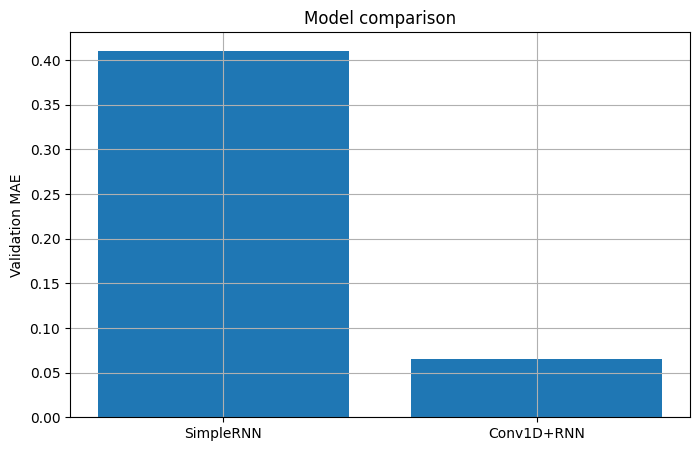

In [ ]:


# Этап 2.2 — Подготовка и нормализация данных

float_data = df.iloc[:,1:].values

mean = float_data[:200000].mean(axis=0)
float_data -= mean

std = float_data[:200000].std(axis=0)
float_data /= std


# Этап 2.3 — Разделение данных Train / Validation / Test

num_train = 200000
num_val = 50000

train_data = float_data[:num_train]
val_data = float_data[num_train:num_train+num_val]
test_data = float_data[num_train+num_val:]


# Этап 2.4 — Создание генератора данных
# 10 дней истории, задержка 1 день, 1 значение в час

sampling_rate = 6
sequence_length = 240
delay = 144
batch_size = 128

train_dataset = timeseries_dataset_from_array(
    data=train_data[:-delay],
    targets=train_data[sequence_length+delay:,1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size
)

val_dataset = timeseries_dataset_from_array(
    data=val_data[:-delay],
    targets=val_data[sequence_length+delay:,1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size
)

test_dataset = timeseries_dataset_from_array(
    data=test_data[:-delay],
    targets=test_data[sequence_length+delay:,1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size
)

for x,y in train_dataset.take(1):
    print("Input:",x.shape)
    print("Target:",y.shape)


# Этап 2.5 — Создание рекуррентной сети SimpleRNN
# Вариант 8: SimpleRNN 128 -> Dropout 0.4 -> SimpleRNN 32 -> Dropout 0.4

model_rnn = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(240,14)),
    Dropout(0.4),
    SimpleRNN(32),
    Dropout(0.4),
    Dense(1)
])

model_rnn.summary()


# Этап 2.6 — Компиляция и обучение модели

model_rnn.compile(
    optimizer=RMSprop(),
    loss="mse",
    metrics=["mae"]
)

history_rnn = model_rnn.fit(
    train_dataset,
    epochs=40,
    validation_data=val_dataset
)


# Этап 2.7 — Графики функции потерь и качества

plt.figure(figsize=(10,5))
plt.plot(history_rnn.history["mae"],label="Train")
plt.plot(history_rnn.history["val_mae"],label="Validation")
plt.title("SimpleRNN MAE")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history_rnn.history["loss"],label="Train")
plt.plot(history_rnn.history["val_loss"],label="Validation")
plt.title("SimpleRNN Loss")
plt.legend()
plt.grid()
plt.show()


# Этап 2.8 — Предсказание температуры

pred_rnn = model_rnn.predict(test_dataset)

real=[]

for x,y in test_dataset.take(1):
    real=y.numpy()

plt.figure(figsize=(10,5))
plt.plot(real[:50],label="Real")
plt.plot(pred_rnn[:50],label="Prediction")
plt.title("Temperature prediction SimpleRNN")
plt.legend()
plt.grid()
plt.show()


# Этап 2.9 — Conv1D(3 слоя) + рекуррентный блок варианта

model_conv_rnn = Sequential([
    Conv1D(32,5,activation="relu",input_shape=(240,14)),
    MaxPooling1D(3),
    Conv1D(32,5,activation="relu"),
    MaxPooling1D(3),
    Conv1D(32,5,activation="relu"),
    SimpleRNN(128,return_sequences=True),
    Dropout(0.4),
    SimpleRNN(32),
    Dropout(0.4),
    Dense(1)
])

model_conv_rnn.summary()


# Этап 2.10 — Обучение Conv1D + RNN

model_conv_rnn.compile(
    optimizer=RMSprop(),
    loss="mse",
    metrics=["mae"]
)

history_conv = model_conv_rnn.fit(
    train_dataset,
    epochs=40,
    validation_data=val_dataset
)


# Этап 2.11 — Сравнение результатов моделей

rnn_mae = min(history_rnn.history["val_mae"])
conv_mae = min(history_conv.history["val_mae"])

print("SimpleRNN MAE:",rnn_mae)
print("Conv1D + RNN MAE:",conv_mae)

plt.figure(figsize=(8,5))
plt.bar(["SimpleRNN","Conv1D+RNN"],[rnn_mae,conv_mae])
plt.title("Model comparison")
plt.ylabel("Validation MAE")
plt.grid()
plt.show()

По графику прогнозирования видно, что модель смогла выявить общие закономерности временного ряда, однако форма предсказанной кривой заметно отличается от реальной температуры. Это говорит о том, что SimpleRNN способна выполнять прогнозирование, но её точность ограничена. Для повышения качества можно использовать более сложные архитектуры, например GRU или LSTM, однако в данной работе использовалась архитектура SimpleRNN согласно варианту задания.

Для оценки качества моделей использовалась метрика MAE. Модель SimpleRNN показала ошибку около 0.41, тогда как гибридная модель Conv1D + SimpleRNN показала ошибку около 0.066. Это означает, что добавление сверточного блока позволило значительно повысить точность прогнозирования. Сверточные слои выделяют локальные особенности временного ряда, а рекуррентные слои анализируют их временные зависимости. В результате гибридная архитектура оказалась существенно эффективнее обычной рекуррентной сети.